## Deep Reinforcement Learning on Grid World Assignment

### Instructions :

1. Initialisez le Grid World avec une largeur, une hauteur et des positions bloquées données.
    - Créez une grille bidimensionnelle représentant le monde avec la largeur et la hauteur spécifiées.
    - Marquez toutes les positions bloquées sur la grille.
    - Spécifiez une position de départ et une position d'arrivée sur la grille.
    - Lancez une simulation avec un agent aléatoire.

2. Créez un Replay Buffer (mémoire tampon de rejouement).
    - Implémentez une classe Replay Buffer capable de stocker et d'échantillonner des expériences pour entraîner l'agent DQN.
    - Chaque expérience doit contenir l'état courant, l'action effectuée, la récompense reçue, l'état suivant et un indicateur (done) signalant si l'épisode est terminé.

3. Créez un réseau de neurones convolutif pour l'apprentissage d'un agent DQN.
    - Définissez un CNN avec Pytorch contenant 3 couches de convolution et 2 couches linéaires.

4. Implémentez un agent DQN pour naviguer dans le Grid World.
    - Implémentez une classe d'agent DQN qui utilise un réseau de neurones pour approximer les Q-valeurs pour chaque paire état-action.
    - Utilisez une politique epsilon-greedy pour sélectionner les actions pendant l'entraînement.
    - Utilisez le replay buffer pour échantillonner des expériences et entraîner l'agent DQN à mettre à jour ses Q-valeurs.
    - Entraînez l'agent à atteindre la position d'arrivée depuis la position de départ tout en évitant les positions bloquées.

5. Expérimentation
    - Entraînez l'agent DQN à naviguer de la position de départ à la position d'arrivée tout en évitant les positions bloquées.
    - Expérimentez avec différentes valeurs d'hyperparamètres, comme le taux d'apprentissage, le facteur d'actualisation, la taille du batch, la récompense, et observez leurs effets sur l'apprentissage de l'agent DQN.
    - Analysez la performance de l'agent en mesurant le nombre d'étapes nécessaires pour atteindre l'objectif à chaque épisode.

6. Simulation
    - Visualisez le chemin de l'agent de la position de départ à la position d'arrivée.
    - Simulez l'agent avec la politique sauvegardée à un épisode spécifique.

7. (Optionnel)
    - Proposez une configuration difficile et observez la performance de l'agent DQN.

8. Questions :
    - Expliquez le rôle du réseau de neurones et la motivation de son utilisation.
    - Expliquez le rôle de la mémoire de rejouement et du minibatch.
    - Expliquez le choix des différents composants de la mémoire de rejouement et leur importance dans l'apprentissage.
    - Expliquez la relation entre la fonction de perte du DQN et la fonction de mise à jour des Q-valeurs dans le Q-Learning.


INTRO : A faire
à améliorer : Erreur dans get_state() 

## Pourquoi le DQN ?

Avant d’introduire le Deep Q-Network (DQN), il est nécessaire de comprendre pourquoi il a été développé. En apprentissage par renforcement, l’objectif est d’estimer une fonction de valeur d’action notée $Q(s,a)$, qui mesure la qualité d’une action $a$ dans un état $s$.

Une première approche consiste à utiliser une Q-table, où chaque paire état-action possède une valeur stockée explicitement. Cette méthode devient rapidement impraticable lorsque l’espace d’état est grand, car elle nécessite de stocker $|S| \times |A|$ valeurs. De plus, l’apprentissage est lent, car il faut explorer un grand nombre de fois les états, et il n’y a aucune généralisation : chaque état est traité indépendamment. Enfin, pour des états continus, il faut discrétiser, ce qui introduit des erreurs et reste difficile à calibrer.

Pour pallier ces limites, on peut utiliser une approximation linéaire de la fonction $Q$, définie par $Q_w(s,a) = \sum_i w_i f_i(s,a)$, où $f_i(s,a)$ sont des caractéristiques et $w_i$ des poids appris. Cette approche réduit la mémoire et permet une certaine généralisation. Toutefois, elle dépend fortement du choix des caractéristiques, souvent difficile à concevoir, et reste limitée car elle ne peut modéliser que des relations linéaires.

La solution consiste alors à utiliser une approximation non linéaire, typiquement via un réseau de neurones. Celui-ci permet d’approximer directement la fonction $Q(s,a)$ en apprenant automatiquement des représentations pertinentes à partir des données. Il est capable de capturer des relations complexes et de généraliser à des états jamais vus.

Le DQN repose précisément sur cette idée : remplacer la Q-table ou les modèles linéaires par un réseau de neurones afin de traiter efficacement des espaces d’état de grande dimension.
On va maintenant appliquer cette méthode dans l'exemple de GridWorld : 

### GridWorld Environment

In [34]:
from collections import deque

On définit premièrement l’environnement GridWorld, pour entraîner notre agent par DQN ; l’ensemble simule une grille dans laquelle un agent (le joueur) doit se déplacer pour atteindre un objectif.
L’agent interagit avec cet environnement en choisissant des actions (haut, bas, gauche, droite), ce qui modifie sa position dans la grille.
À chaque déplacement, il reçoit une récompense qui guide son apprentissage et lui permet d’évaluer la qualité de ses actions.
L’objectif est alors d’apprendre une stratégie optimale permettant d’atteindre la cible le plus efficacement possible.

Remarque : La fonction de récompense a été modifiée pour renforcer le signal d’apprentissage (récompense plus élevée pour l’objectif et pénalité plus forte par étape). Avoir des rewards optimisé améliore la vitesse de convergence. à verif

In [35]:
import random
import numpy as np
class GridWorld:
    def __init__(self, width, height, blocked_positions=None):

        self.width = width
        self.height = height
        self.player_position = (0, 0)
        self.goal_position = (width - 1, height - 1)
        self.blocked_positions = blocked_positions if blocked_positions else []
        self.observation_space = (2, self.height, self.width)
        self.action_space = 4
        self.actions = ["up", "down", "left", "right",]

    def make_action(self, action:int):
        self.move_player(self.actions[action])

    def move_player(self, direction):
        x, y = self.player_position
        if direction == "up":
            y = max(0, y - 1)
        elif direction == "down":
            y = min(self.height - 1, y + 1)
        elif direction == "left":
            x = max(0, x - 1)
        elif direction == "right":
            x = min(self.width - 1, x + 1)
        
        # Check if the new position is blocked
        if (x, y) not in self.blocked_positions:
            self.player_position = (x, y)
        return self.player_position == self.goal_position

    def print_grid(self):
        for y in range(self.height):
            row = ""
            for x in range(self.width):
                if (x, y) == self.player_position:
                    row += "P"
                elif (x, y) == self.goal_position:
                    row += "G"
                elif (x, y) in self.blocked_positions:
                    row += "B"
                else:
                    row += "."
            print(row)
            
    def is_game_over(self):
        return self.player_position == self.goal_position
    
    def get_state(self):
        state = np.zeros((2, self.height, self.width))
        x, y = self.player_position
        state[0][y, x] = 1 #Correction des indices (x, y) → (row, col) dans get_state() afin d’assurer une cohérence spatiale correcte pour l’entrée du réseau.
        for  block_x, block_y  in self.blocked_positions:
            state[1][block_x, block_y] = 1
        return state

    def get_reward(self):
        if self.is_game_over():
            return 10  # forte récompense pour atteindre l'objectif
        else:
            return -0.1  # pénalité à chaque étape pour encourager les chemins courts
    
    def reset(self):
        # Reset the player's position to (0, 0)
        self.player_position = (0, 0)

### Visualisation GridWorld

Cette partie permet d’afficher l’environnement GridWorld avec `pygame`.  
La grille représente l’agent (rouge), l’objectif (vert) et les obstacles (bleu).
À chaque itération, l’agent se déplace aléatoirement, ce qui permet de vérifier le bon fonctionnement de l’environnement. Ce module sert uniquement à la visualisation et constitue une base avant l’intégration du DQN.

In [36]:
import pygame
import random

# Define grid cell size and margin
CELL_SIZE = 50
MARGIN = 5

# Define colors
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
GREEN = (0, 255, 0)
RED = (255, 0, 0)
BLUE = (0, 0, 255)

def draw_grid(screen, grid_world):
    for y in range(grid_world.height):
        for x in range(grid_world.width):
            color = WHITE
            if (x, y) == grid_world.player_position:
                color = RED
            elif (x, y) == grid_world.goal_position:
                color = GREEN
            elif (x, y) in grid_world.blocked_positions:
                color = BLUE

            pygame.draw.rect(
                screen,
                color,
                [
                    (MARGIN + CELL_SIZE) * x + MARGIN,
                    (MARGIN + CELL_SIZE) * y + MARGIN,
                    CELL_SIZE,
                    CELL_SIZE
                ]
            )

def main():
    pygame.init()

    grid_world = GridWorld(5, 5, blocked_positions=[(1, 1), (2, 2), (3, 3)])
    directions = ["up", "down", "left", "right"]

    screen = pygame.display.set_mode([
        (CELL_SIZE + MARGIN) * grid_world.width + MARGIN,
        (CELL_SIZE + MARGIN) * grid_world.height + MARGIN
    ])
    pygame.display.set_caption("GridWorld")

    clock = pygame.time.Clock()
    running = True

    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        if not grid_world.is_game_over():
            direction = random.choice(directions)
            grid_world.move_player(direction)

        screen.fill(BLACK)
        draw_grid(screen, grid_world)
        pygame.display.flip()

        clock.tick(10)  # ralentir pour voir les mouvements

    pygame.quit()

if __name__ == "__main__":
    main()

## Architecture du DQN

Le réseau prend en entrée un état sous forme de tenseur de dimension (2, H, W), où les deux canaux représentent respectivement la position de l’agent et les obstacles dans la grille. Lors de l’entraînement, ces états sont traités par batch, donnant une entrée de forme (batch_size, 2, H, W).

Les couches convolutionnelles ont pour rôle d’extraire des caractéristiques spatiales pertinentes de l’environnement. Elles permettent de détecter des structures locales (proximité d’un obstacle, direction du but) et de construire progressivement des représentations plus abstraites grâce à l’empilement des couches et aux activations non linéaires.

La partie fully connected prend ensuite ces features et les transforme en valeurs associées à chaque action possible. La couche de sortie réalise un mapping direct vers l’ensemble des actions disponibles (one output per action), en produisant une valeur Q pour chacune d’entre elles dans l’état courant. Cela revient, en pratique, à approximer une Q-table : au lieu de stocker explicitement Q(s, a), le réseau la prédit directement.

Le réseau ne choisit pas directement une action. Il calcule simplement un score (valeur Q) pour chaque action possible. Ensuite, l’agent utilise ces scores pour décider : soit il prend l’action avec le score le plus élevé, soit il choisit aléatoirement (pour explorer).

Remarque : Enfin, cette architecture ressemble fortement à celle des ConvNets utilisés en vision : les convolutions extraient des patterns spatiaux, puis les couches fully connected exploitent ces représentations pour produire une sortie. Ici, la différence est que la sortie n’est pas une classe, mais une estimation des valeurs d’actions.



## FIRE UN COMPARAISON AVEC ET SANS DROPOUT POUR LEMMTDAPRES CHAT CA RAJT DE LINSTABILIT2

In [37]:
import matplotlib.pyplot as plt
import pickle
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
class DQN(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(DQN, self).__init__()
        # Define the convolutional layers
        self.conv1 = nn.Conv2d(input_shape[0], 16, kernel_size=5, stride=1)
        #self.dropout1 = nn.Dropout(p=0.5)
        self.conv2 = nn.Conv2d(16,32, kernel_size=4, stride=1)
        #self.dropout2 = nn.Dropout(p=0.5)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1)
        #self.dropout3 = nn.Dropout(p=0.5)
        # Define the fully connected layers
        self.fc1 = nn.Linear(self.feature_size(input_shape), 512)
        #self.dropout4 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(512, num_actions)

###
#    def forward(self, x):
 #       # Pass the input through the convolutional layers
  #      x = F.relu(self.conv1(x))
   #     #x = self.dropout1(x)
        #x = F.relu(self.conv2(x))
 #       x = self.dropout2(x)
        #x = F.relu(self.conv3(x))
   #     x = self.dropout3(x)
        # Flatten the output and pass it through the fully connected layers
    #    x = F.relu(self.fc1(x.view(x.size(0), -1)))
        #x = self.dropout4(x)
     #   return self.fc2(x)


    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)



    def feature_size(self, input_shape):
        # Compute the size of the output of the convolutional layers
        print(input_shape)
        x = self.conv1(torch.zeros(1, *input_shape))
        x = self.conv2(x)
        x = self.conv3(x)
        return x.view(1, -1).size(1)




## DQN agent : 

Cette cellule implémente un agent DQN qui choisit des actions, stocke ses expériences et met à jour un réseau de neurones en minimisant l’erreur entre les valeurs Q prédites et des cibles construites à partir du futur. En apprentissage par renforcement, on cherche à approximer une fonction $Q_\omega(s,a)$ paramétrée par les poids du réseau $\omega$. Contrairement au supervised learning, la vraie valeur cible de $Q(s,a)$ est inconnue. On utilise donc un mécanisme d’amorçage basé sur l’équation de Bellman. À chaque interaction $(s, a, s', r)$, on effectue d’abord un **premier passage forward (feedforward)** pour prédire la valeur actuelle :
$\hat{y} = Q_\omega(s,a)$.

Ensuite, on construit une cible en utilisant un **second forward pass** sur l’état suivant :
$y = r + \gamma \max_{b \in A} Q_\omega(s', b)$.

Ce point est central : la cible dépend du modèle lui-même, ce qui caractérise le Q-Learning avec réseau de neurones (naïf). On obtient alors un apprentissage de type supervisé en minimisant une fonction de perte, généralement la MSE :
$J(\omega) = (y - \hat{y})^2$. Le gradient de cette perte (en supposant $y$ indépendant de $\omega$) est :
$\nabla_\omega J(\omega) = -2 (y - \hat{y}) \nabla_\omega \hat{y}$.

On met ensuite à jour les poids par descente de gradient :
$\omega \leftarrow \omega - \alpha \nabla_\omega J(\omega)$,

ce qui revient à :
$\omega \leftarrow \omega + \alpha \big(r + \gamma \max_{b \in A} Q_\omega(s', b) - Q_\omega(s,a)\big)\nabla_\omega Q_\omega(s,a)$.

Ainsi, à chaque itération, le réseau ajuste ses prédictions pour respecter la contrainte de Bellman :
$Q(s,a) \approx r + \gamma \max_b Q(s',b)$.
C’est cette cohérence entre présent et futur qui permet la convergence progressive.

Au début, l’agent ne connaît pas les bonnes actions et explore largement (ε-greedy), testant différentes actions de manière aléatoire. C’est uniquement en explorant qu’il peut tomber sur des récompenses, qui servent ensuite de signal d’apprentissage. Une fois une récompense observée, l’information se propage vers les états précédents via les mises à jour successives, ce qui permet d’identifier progressivement les bonnes décisions.

Enfin, la qualité des récompenses joue un rôle crucial. Des récompenses trop rares (uniquement en fin d’épisode) rendent l’apprentissage difficile, car l’agent doit explorer longtemps avant d’obtenir un signal. À l’inverse, des récompenses intermédiaires bien conçues peuvent accélérer l’apprentissage en guidant l’agent, à condition qu’elles restent cohérentes avec l’objectif global. L’apprentissage repose donc sur un équilibre entre exploration (découverte des récompenses) et exploitation (utilisation des connaissances acquises), permettant au modèle d’améliorer progressivement sa politique.


#### Pourquoi Pytorch ? 
PyTorch est utilisé ici car il offre une grande flexibilité pour implémenter la boucle d’apprentissage personnalisée du DQN, notamment pour gérer les deux passages forward, le calcul manuel de la cible et la mise à jour des poids.


In [38]:
import copy
import random
import numpy as np
import torch
import torch.nn.functional as F

class DQNAgent:
    def __init__(
        self,
        alpha=0.001,
        gamma=0.99,
        epsilon=1.0,
        epsilon_min=0.01,
        dqn_model=None,
        device=None
    ):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min

        self.device = device if device is not None else torch.device(
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.dqn_model = dqn_model.to(self.device)

        # Target network
        self.target_model = copy.deepcopy(self.dqn_model).to(self.device)
        self.target_model.eval()

        self.optimizer = None
        self.memory = None
        self.batch_size = None
        self.loss = None

    def get_q_value(self, state, action=None):
        state_tensor = torch.tensor(
            np.array(state),
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(0)

        self.dqn_model.eval()
        with torch.no_grad():
            q_values = self.dqn_model(state_tensor)

        if action is None:
            return q_values.cpu()
        else:
            return q_values[0, action].cpu()

    def update_epsilon(self, epsilon_decay=0.99):
        self.epsilon = max(self.epsilon_min, self.epsilon * epsilon_decay)

    def get_action(self, state, action_size=4):
        if random.random() < self.epsilon:
            return random.randint(0, action_size - 1)

        state_tensor = torch.tensor(
            np.array(state),
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(0)

        self.dqn_model.eval()
        with torch.no_grad():
            q_values = self.dqn_model(state_tensor)

        return q_values.argmax(dim=1).item()

    def learn_from_memory(self, memory_batch):
        state_batch, action_batch, reward_batch, next_state_batch, done_batch = memory_batch

        state_tensor = torch.tensor(
            np.array(state_batch),
            dtype=torch.float32,
            device=self.device
        )

        action_tensor = torch.tensor(
            action_batch,
            dtype=torch.int64,
            device=self.device
        ).unsqueeze(1)

        reward_tensor = torch.tensor(
            reward_batch,
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(1)

        next_state_tensor = torch.tensor(
            np.array(next_state_batch),
            dtype=torch.float32,
            device=self.device
        )

        done_tensor = torch.tensor(
            done_batch,
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(1)

        # Q(s,a) prédit par le réseau principal
        self.dqn_model.train()
        q_values = self.dqn_model(state_tensor).gather(1, action_tensor)

        # Cible y calculée avec le target network
        with torch.no_grad():
            next_q_values = self.target_model(next_state_tensor).max(dim=1)[0].unsqueeze(1)
            expected_q_values = reward_tensor + self.gamma * next_q_values * (1 - done_tensor)

        # Huber loss
        loss = F.smooth_l1_loss(q_values, expected_q_values)

        self.optimizer.zero_grad()
        loss.backward()

        # Stabilisation des gradients
        torch.nn.utils.clip_grad_norm_(self.dqn_model.parameters(), max_norm=1.0)

        self.optimizer.step()

        self.loss = loss.detach().cpu().item()

    def learn(self, batch_size=None):
        if batch_size is None:
            batch_size = self.batch_size

        if len(self.memory) < batch_size:
            return

        batch = self.memory.get_batch(batch_size)
        self.learn_from_memory(batch)

    def update_target_network(self):
        self.target_model.load_state_dict(self.dqn_model.state_dict())

    def set_optimizer(self, optimizer):
        self.optimizer = optimizer

    def set_memory(self, memory):
        self.memory = memory

    def set_batch_size(self, batch_size):
        self.batch_size = batch_size

En Deep Q-Learning, un problème majeur vient des **corrélations entre les interactions** $(s, a, s', r)$, qui sont générées de manière séquentielle. En effet, chaque action influence directement l’état suivant, ce qui rend les données fortement dépendantes. Contrairement au cadre supervisé classique, ces données ne sont donc pas i.i.d. (indépendantes et identiquement distribuées). Cela pose problème, car une mise à jour du réseau sur une transition donnée peut perturber l’apprentissage global et entraîner des modifications non contrôlées sur d’autres couples $(s,a)$, ce qui peut ralentir l’apprentissage ou provoquer une divergence.

Pour corriger cela, on utilise le mécanisme d’**Experience Replay**. Le principe consiste à stocker toutes les interactions rencontrées dans un buffer appelé *Replay Memory*. L’apprentissage est alors découpé en deux processus : d’un côté, l’agent interagit avec l’environnement et collecte des transitions ; de l’autre, le réseau est entraîné en tirant aléatoirement des mini-batchs depuis ce buffer. Ce tirage aléatoire permet de casser les corrélations temporelles entre les données, rapprochant ainsi l’apprentissage d’un cadre i.i.d. De plus, une même interaction peut être réutilisée plusieurs fois, ce qui améliore l’efficacité des données et accélère la convergence. Enfin, cela permet de limiter l’oubli catastrophique en réintroduisant régulièrement des expériences anciennes ou rares dans le processus d’apprentissage.

Dans notre implémentation, nous introduisons également une variante du replay buffer en sur-échantillonnant certaines expériences, notamment les trajectoires positives menant à une récompense élevée. Cette approche, appelée biased replay buffer, vise à renforcer l’apprentissage des transitions les plus informatives et à accélérer la propagation des récompenses dans le réseau. Cependant, elle modifie la distribution des données et peut introduire un biais dans l’estimation des valeurs, ce qui constitue un compromis entre efficacité d’apprentissage et respect de l’hypothèse i.i.d.

Remarque : un autre problème d’instabilité provient du fait que la cible $y = r + \gamma \max_{b \in A} Q_\omega(s', b)$ dépend directement des paramètres du réseau. Une solution classique consiste à utiliser un **réseau cible (target network)**, qui stabilise l’apprentissage en fournissant une cible plus fixe.


In [39]:
class ReplayMemory:
    def __init__(self, capacity):
        # Initializes the ReplayMemory class with a given capacity.
        self.capacity = capacity
        self.memory = deque(maxlen=capacity)
        self.current_episode = []
        self.neg_memory = deque(maxlen=capacity)
        self.pos_trajectory_memory = deque(maxlen=capacity)
        self.pos_memory = deque(maxlen=capacity)

    def new_episode(self):
        # Clears the current episode.
        self.current_episode = []

    def push(self, state, action, reward, next_state, done):
        # Adds a new experience to the memory.
        self.memory.append((state, action, reward, next_state, done))
        self.current_episode.append((state, action, reward, next_state, done))
        if reward < -0.01:
            self.neg_memory.append((state, action, reward, next_state, done))
        if reward > 0.01:
            self.pos_memory.append((state, action, reward, next_state, done))

    def is_done(self):
        # Returns whether the current episode is done.
        return self.current_episode[-1][4]


    def get_batch(self, batch_size):
        # The function `get_batch` returns a batch of experiences from the memory. 
        # The batch is composed of three different types of experiences: `batch`, 
        # `pos_trajectory_batch`, and `pos_batch`. 

        # `batch` is a random sample of experiences from the memory. 

        # `pos_trajectory_batch` is a random sample of experiences from the `pos_trajectory_memory` deque.
        #  
        # `pos_batch` is a random sample of experiences from the `pos_memory` deque. 

        # The `pos_trajectory_memory` deque is used to store experiences that have a 
        # positive reward and are part of a trajectory that led to a positive reward. 

        # The `pos_memory` deque is used to store experiences that have a positive reward 
        # but are not part of a trajectory that led to a positive reward. 
        
        # The purpose of having separate batches for positive experiences is to ensure that 
        # the agent learns from positive experiences more frequently.

        pos_trajectory_batch = random.sample(self.pos_trajectory_memory, min(len(self.pos_trajectory_memory), batch_size//3))
        pos_batch = random.sample(self.pos_memory, min(len(self.pos_memory), batch_size//3))
        batch = random.sample(self.memory, min(len(self.memory), batch_size - len(pos_trajectory_batch) - len(pos_batch)))
        batch = batch + pos_trajectory_batch + pos_batch
        state_batch = []
        action_batch = []
        reward_batch = []
        next_state_batch = []
        done_batch = []
        for state, action, reward, next_state, done in batch:
            state_batch.append(state)
            action_batch.append(action)
            reward_batch.append(reward)
            next_state_batch.append(next_state)
            done_batch.append(done)
        return state_batch, action_batch, reward_batch, next_state_batch, done_batch

    def __len__(self):
        # Returns the length of the memory.
        return len(self.memory)
    
    def add_episode_pos(self):
        # Add positive trajectory samples into pos_trajectory_memory.
        self.pos_trajectory_memory.extend(self.current_episode)
        self.new_episode()




## Résultat et analyse théorique du DQN

Cette fonction réalise l’entraînement complet d’un agent DQN sur GridWorld. Elle commence par initialiser l’environnement, le réseau, l’agent, l’optimiseur et la replay memory. Une phase de **warm-up** est ensuite effectuée, durant laquelle l’agent explore aléatoirement et remplit la mémoire avec des transitions $(s,a,s',r)$ sans apprentissage. Cette étape permet de disposer d’un ensemble de données initial avant l’optimisation.

Lors de la phase de **training**, l’agent interagit avec l’environnement à chaque épisode : il observe un état, choisit une action selon une politique $\epsilon$-greedy, reçoit une récompense et stocke la transition. Le réseau est ensuite mis à jour à partir de mini-batchs issus de la replay memory. L’apprentissage repose sur deux passages forward : le premier calcule la prédiction $\hat{y} = Q_\omega(s,a)$, et le second permet de construire la cible
$$
y = r + \gamma \max_{b \in A} Q_\omega(s', b).
$$
La minimisation de la loss (Huber ou MSE) force le modèle à satisfaire localement l’équation de Bellman, assurant une cohérence entre états successifs.

Au début de l’entraînement, l’agent évolue dans un régime d’**exploration quasi pure** ($\epsilon \approx 1$), où les actions sont majoritairement aléatoires. Les transitions sont peu informatives et les récompenses cumulées sont faibles (voire négatives), reflétant une fonction $Q_\omega$ encore non structurée. À mesure que l’entraînement progresse et que $\epsilon$ diminue, l’agent entre dans une phase d’**exploitation** : il utilise les connaissances acquises pour privilégier les actions menant à de meilleures récompenses.

Les premières récompenses positives jouent un rôle fondamental : elles agissent comme des **points d’ancrage**, à partir desquels l’information se propage rétroactivement via les mises à jour de Bellman. Cette propagation permet à l’agent d’identifier progressivement les trajectoires efficaces, ce qui se traduit par une augmentation de la récompense cumulée et une diminution du nombre de steps par épisode. La pénalité par pas $(-0.01)$ introduit une contrainte supplémentaire favorisant les chemins courts, expliquant une convergence vers une récompense inférieure à 1.

L’**Experience Replay** permet de stabiliser l’apprentissage en cassant les corrélations temporelles entre les transitions et en rapprochant le processus d’un cadre i.i.d. De plus, la réutilisation des expériences améliore l’efficacité des données et limite l’oubli. Combiné à l’approximation non linéaire du réseau de neurones, ce mécanisme permet au DQN de converger vers une approximation stable de la fonction optimale $Q^*$.

Par ailleurs, le Deep Q-Learning standard peut souffrir d’un biais de surestimation des Q-valeurs (overestimation bias). Ce phénomène provient de l’utilisation de l’opérateur $\max$ dans la construction de la cible, qui tend à sélectionner des valeurs surestimées. Une amélioration classique consiste à utiliser Double DQN, qui dissocie la sélection de l’action et son évaluation, réduisant ainsi ce biais et améliorant la stabilité de l’apprentissage.

En résumé, le processus suit une dynamique classique : **exploration → collecte → apprentissage → propagation des récompenses → convergence vers une politique optimale**.

(2, 10, 10)
Warm up..
50000 217 50000
Training..
episode_ 0
episode 0, cumulated_reward -50.00, step 500, loss 0.01369, epsilon 0.99
episode 1, cumulated_reward -33.20, step 433, loss 0.00034, epsilon 0.97
episode 2, cumulated_reward -50.00, step 500, loss 0.00387, epsilon 0.95
episode 3, cumulated_reward -50.00, step 500, loss 0.00000, epsilon 0.93
episode 4, cumulated_reward -50.00, step 500, loss 0.00002, epsilon 0.91
episode 5, cumulated_reward -50.00, step 500, loss 0.00008, epsilon 0.89
episode 6, cumulated_reward -30.90, step 410, loss 0.00000, epsilon 0.88
episode 7, cumulated_reward -50.00, step 500, loss 0.00176, epsilon 0.86
episode 8, cumulated_reward -50.00, step 500, loss 0.00007, epsilon 0.84
episode 9, cumulated_reward -16.80, step 269, loss 0.00069, epsilon 0.83
episode_ 10
episode 10, cumulated_reward -11.70, step 218, loss 0.00016, epsilon 0.81
episode 11, cumulated_reward -35.90, step 460, loss 0.00001, epsilon 0.79
episode 12, cumulated_reward -50.00, step 500, los

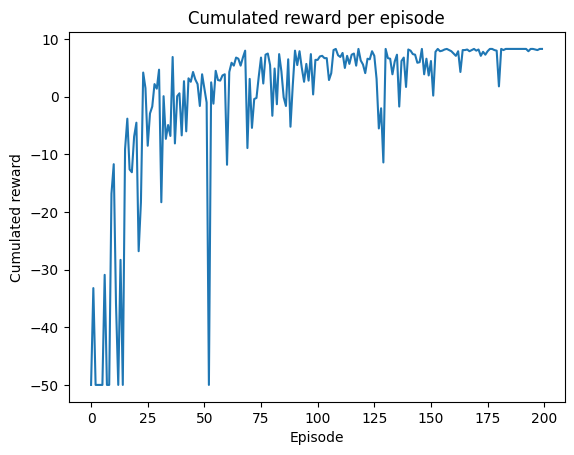

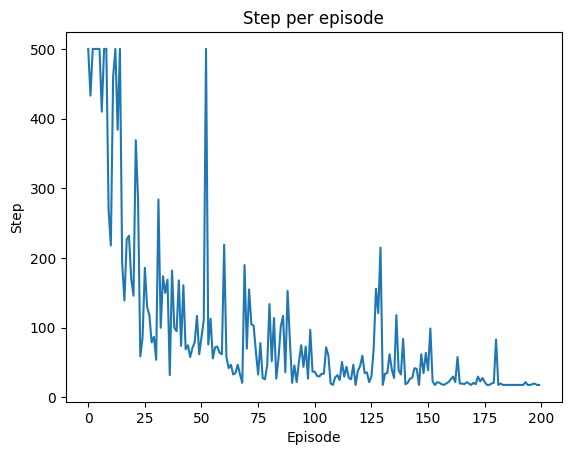

In [40]:
from IPython.display import clear_output
import time
def ExperimentDQNAgent():
    grid_world = GridWorld(10, 10, blocked_positions=[(1, 1), (2, 2), (3, 3), (4, 4), (3, 2), (3, 1), (5,0),
                                                        (5, 5),  (8, 9),  (8, 8),  (8, 7),])
    dqn_model = DQN(grid_world.observation_space, grid_world.action_space)
    agent = DQNAgent(alpha=0.001, gamma=0.95, epsilon=0.99, dqn_model=dqn_model)
    optimizer = optim.Adam(dqn_model.parameters(), lr=0.001)
    memory = ReplayMemory(capacity=50000)
    agent.set_optimizer(optimizer)
    agent.set_memory(memory)
    agent.set_batch_size(128) 

    num_episodes = 200
    batch_size = 128
    step_per_episode = []
    cumulated_reward_per_episode = []
    loss = []
    
    #warm up, save examples into memory
    print("Warm up..")
    for episode in range(1000):    
        grid_world.reset()
        step=0
        while not grid_world.is_game_over() and step < 500:
            step += 1
            state = grid_world.get_state()
            agent.dqn_model.eval()
            action = agent.get_action(state)
            grid_world.make_action(action)
            next_state = grid_world.get_state()
            reward = grid_world.get_reward()
            done = grid_world.is_game_over()
            agent.memory.push(state, action, reward, next_state, done)
            state = next_state
        if reward > 0:
            agent.memory.add_episode_pos()    

    print(len(agent.memory.memory), len(agent.memory.pos_memory), len(agent.memory.neg_memory), )

    #learning
    print("Training..")
    for episode in range(num_episodes):
        if episode % 10 == 0:
            print("episode_", episode)
        if episode % 10 == 0:
            agent.update_target_network()
            torch.save(agent.dqn_model.state_dict(), f'grid_world_learned_policy_dqn_{episode}.pt')
        grid_world.reset()
        cumulated_reward = 0
        step=0
        q_values_of_state=[]
        while not grid_world.is_game_over() and step < 500:
            step += 1
            state = grid_world.get_state()
            agent.dqn_model.eval()
            action = agent.get_action(state)
            grid_world.make_action(action)
            next_state = grid_world.get_state()
            reward = grid_world.get_reward()
            done = grid_world.is_game_over()
            #print(state, action, reward)
            q_values_of_state.append(agent.get_q_value(state).numpy())
            agent.memory.push(state, action, reward, next_state, done)
            state = next_state
            cumulated_reward += reward    
            agent.dqn_model.train()
            agent.learn(batch_size=batch_size)
        cumulated_reward_per_episode.append(cumulated_reward)
        step_per_episode.append(step)
        print(f"episode {episode}, cumulated_reward {cumulated_reward:.02f}, step {step}, loss {agent.loss:.05f}, epsilon {agent.epsilon:.02f}")
        
        if reward > 0:
            agent.memory.add_episode_pos()    
            
        agent.update_epsilon(0.98)
         
    
    plt.plot(cumulated_reward_per_episode)
    plt.title('Cumulated reward per episode')
    plt.xlabel('Episode')
    plt.ylabel('Cumulated reward')
    plt.show()

    plt.plot(step_per_episode)
    plt.title('Step per episode')
    plt.xlabel('Episode')
    plt.ylabel('Step')
    plt.show()

ExperimentDQNAgent()


Cette fonction permet d’évaluer la politique apprise en simulant le comportement de l’agent et en reconstruisant une Q-table approximée à partir des prédictions du réseau, offrant une visualisation de la stratégie optimale.

In [43]:
def SimulationDQNAgent(episode=180):
    grid_world = GridWorld(
        10, 10,
        blocked_positions=[(1, 1), (2, 2), (3, 3), (4, 4),
                           (3, 2), (3, 1), (5, 0),
                           (5, 5), (8, 9), (8, 8), (8, 7)]
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dqn_model = DQN(grid_world.observation_space, grid_world.action_space)
    dqn_model.load_state_dict(torch.load(
        f'grid_world_learned_policy_dqn_{episode}.pt',
        map_location=device
    ))
    dqn_model.to(device)
    dqn_model.eval()

    agent = DQNAgent(alpha=0.5, gamma=0.9, epsilon=0.0, dqn_model=dqn_model)

    # --- DISPLAY ---
    pygame.init()
    screen = pygame.display.set_mode([
        (CELL_SIZE + MARGIN) * grid_world.width + MARGIN,
        (CELL_SIZE + MARGIN) * grid_world.height + MARGIN
    ])
    pygame.display.set_caption("GridWorld")

    running = True
    clock = pygame.time.Clock()
    visited_positions = []

    # --- SIMULATION ---
    while running and not grid_world.is_game_over():
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False

        state = grid_world.get_state()
        action = agent.get_action(state)
        grid_world.make_action(action)

        visited_positions.append(grid_world.player_position)

        screen.fill(BLACK)
        draw_grid(screen, grid_world)

        for i, pos in enumerate(visited_positions):
            x, y = pos
            alpha = int(100 + 155 * (i / len(visited_positions)))
            color = (255, 200, 200, alpha)

            temp_surface = pygame.Surface((CELL_SIZE, CELL_SIZE), pygame.SRCALPHA)
            pygame.draw.rect(temp_surface, color, [0, 0, CELL_SIZE, CELL_SIZE])
            screen.blit(
                temp_surface,
                [(MARGIN + CELL_SIZE) * x + MARGIN,
                 (MARGIN + CELL_SIZE) * y + MARGIN]
            )

        pygame.display.flip()
        clock.tick(10)

    # --- RECONSTRUCTION Q-TABLE ---
    q_table = np.zeros((grid_world.height, grid_world.width))
    action_table = np.empty((grid_world.height, grid_world.width), dtype=object)

    for i in range(grid_world.width):
        for j in range(grid_world.height):
            x, y = i, j

            state = np.zeros((2, grid_world.height, grid_world.width))

            # CORRECTION indices
            state[0][y, x] = 1
            for bx, by in grid_world.blocked_positions:
                state[1][by, bx] = 1

            q_values = agent.get_q_value(state).numpy().flatten()

            q_table[j, i] = np.max(q_values).round(2)
            action_table[j, i] = grid_world.actions[np.argmax(q_values)]

    print("q_table\n", q_table)
    print("action_table\n", action_table)

    pygame.quit()

    # --- VISUALISATION (OPTIONNEL MAIS RECOMMANDÉ) ---
    import matplotlib.pyplot as plt

    plt.figure(figsize=(8, 6))
    plt.imshow(q_table, cmap='viridis')
    plt.colorbar(label='Q-value')
    plt.title('Q-table (max Q per state)')

    for i in range(grid_world.height):
        for j in range(grid_world.width):
            plt.text(j, i, action_table[i, j],
                     ha='center', va='center', color='white', fontsize=8)

    plt.show()

(2, 10, 10)
q_table
 [[3.48000002 4.         4.09000015 4.03000021 4.63000011 5.36999989
  5.21999979 5.30000019 6.51000023 6.69000006]
 [3.66000009 3.56999993 3.75999999 3.76999998 4.86999989 5.38999987
  5.80000019 5.67999983 6.94000006 7.46000004]
 [3.77999997 4.23000002 3.98000002 5.30000019 5.46000004 6.78999996
  6.78000021 6.90999985 7.57999992 7.90999985]
 [3.9000001  4.71999979 4.88000011 4.5        5.94999981 6.55000019
  6.78000021 7.48000002 8.17000008 7.86999989]
 [4.55000019 5.4000001  5.80999994 5.38999987 5.82000017 6.53999996
  7.61999989 8.14000034 8.85000038 8.11999989]
 [4.98000002 5.73999977 6.53999996 6.36000013 6.80999994 6.01000023
  7.96000004 8.18999958 8.76000023 8.67000008]
 [4.98999977 6.01000023 6.98000002 6.90999985 7.26999998 6.69999981
  7.46000004 8.36999989 8.69999981 9.44999981]
 [4.38999987 5.67000008 6.25       6.88000011 7.19000006 6.94999981
  7.94999981 8.31000042 6.94000006 9.21000004]
 [4.38000011 4.75       6.         6.28000021 6.9000001  7.

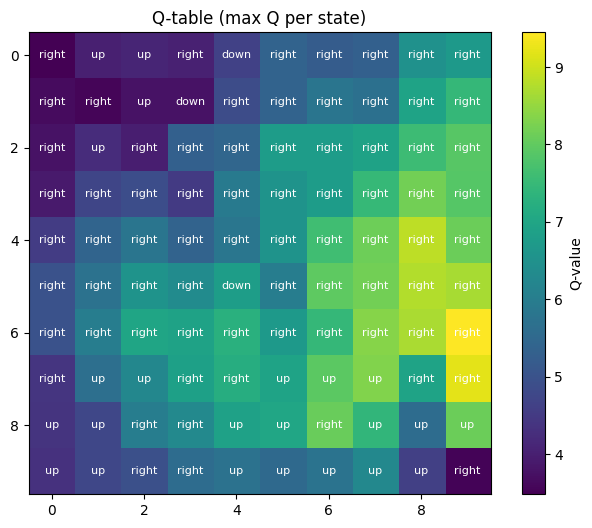

In [44]:
SimulationDQNAgent(episode=180)